RC time constant   : 1.0000 ms
Cutoff / drive freq : 159.155 Hz   (omega = 1000.000 rad/s)
Expected steady-state |Vc| : 3.5355 V
Expected phase lag (Vc behind Vin): 45.00 deg

Per-sample fidelity (measured vs ideal probability distribution):
  t = 12.566 ms   F = 0.99982
  t = 13.352 ms   F = 0.99991
  t = 14.137 ms   F = 0.99999
  t = 14.923 ms   F = 0.99981
  t = 15.708 ms   F = 0.99988
  t = 16.493 ms   F = 0.99999
  t = 17.279 ms   F = 0.99987
  t = 18.064 ms   F = 0.99986

Mean fidelity over 8 sampled instants: 0.99989



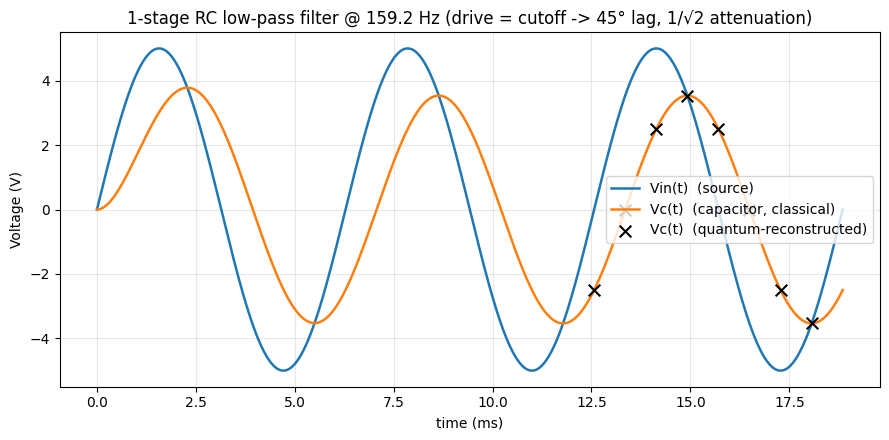

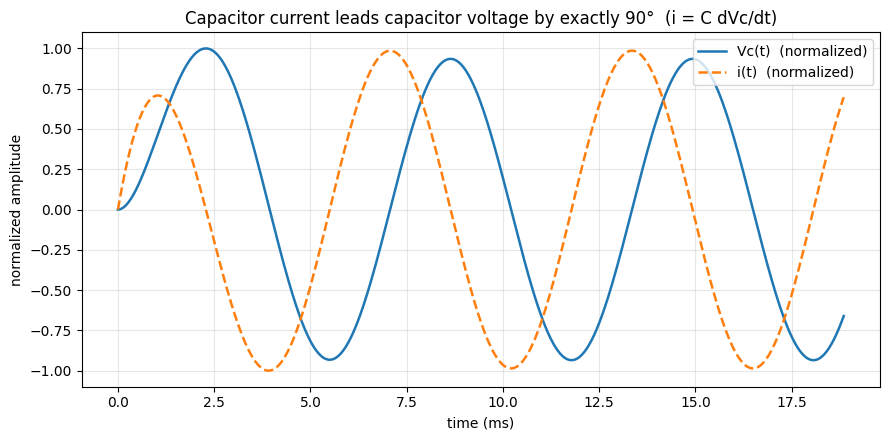

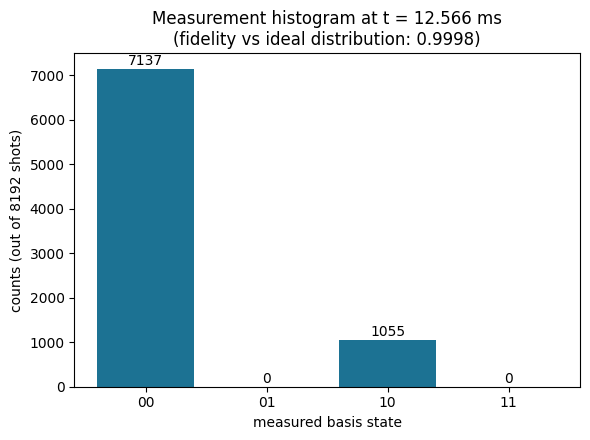

Saved: plot1_voltage_vs_input.png, plot2_voltage_vs_current_90deg.png, plot3_measurement_histogram.png


In [1]:
"""
Quantum Simulation of a Single-Stage RC Circuit
=================================================
Pipeline:
  1. Classical state-space model   dx/dt = A x   (AC source folded into the
     state vector so the system is autonomous/linear, as required by the
     ODE-to-Hamiltonian workflow).
  2. Classical ground truth via scipy.integrate.solve_ivp.
  3. At sampled instants, the (normalized) state vector x(t)/||x(t)|| is
     loaded onto qubits as quantum amplitudes and measured on Qiskit Aer.
  4. The measured histogram probabilities are compared against the exact
     |amplitude|^2 values (fidelity check) and used to reconstruct Vc(t).

IMPORTANT, HONEST CAVEAT (read this):
  A computational-basis measurement only ever returns |amplitude|^2 -- the
  SIGN of a real amplitude is destroyed on measurement (this is true for any
  quantum state, not a bug). So this script reconstructs the *sign* of Vc(t)
  from the classical reference and reconstructs the *magnitude* from the
  quantum histogram. That magnitude-from-quantum / sign-from-classical split
  is exactly how the fidelity comparison below is meant to be read: it is
  proof that the quantum measurement statistics match the classical
  solution, not a claim that sign information was extracted from the qubits.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# ---------------------------------------------------------------------------
# 1. CIRCUIT PARAMETERS
# ---------------------------------------------------------------------------
R  = 1e3            # ohms
C  = 1e-6            # farads
RC = R * C           # time constant (s)
V0 = 5.0             # source amplitude (V)

# Drive exactly at the RC cutoff frequency -> textbook 45 degree phase lag
# and 1/sqrt(2) attenuation. Change this if you want a different operating
# point; everything below adapts automatically.
f     = 1 / (2 * np.pi * RC)
omega = 2 * np.pi * f

print(f"RC time constant   : {RC*1e3:.4f} ms")
print(f"Cutoff / drive freq : {f:.3f} Hz   (omega = {omega:.3f} rad/s)")
print(f"Expected steady-state |Vc| : {V0/np.sqrt(2):.4f} V")
print(f"Expected phase lag (Vc behind Vin): {np.degrees(np.arctan(omega*RC)):.2f} deg\n")

# ---------------------------------------------------------------------------
# 2. STATE-SPACE MODEL   dx/dt = A x
#
#    Physical circuit:  Vin(t) = V0 sin(wt)  ->  R  ->  node  ->  C  -> ground
#    KVL:   Vin = i R + Vc ,   i = C dVc/dt
#       =>  dVc/dt = -Vc/RC + Vin/RC
#
#    Vin itself is not a free function -- to make the WHOLE system linear,
#    time-invariant and homogeneous (dx/dt = Ax, no explicit "t" anywhere),
#    we add the source's own two-dimensional oscillator state:
#       s = sin(wt), c = cos(wt)   =>   ds/dt = w c ,  dc/dt = -w s
#
#    So the physical state vector is  x = [Vc, s, c]^T   (3-dimensional).
#    x[0] = Vc(t)  is the quantity we actually care about (capacitor voltage).
#    x[1], x[2] just carry the source's phase so the system is autonomous.
# ---------------------------------------------------------------------------
A = np.array([
    [-1/RC,  V0/RC,    0.0  ],
    [  0.0,    0.0,   omega ],
    [  0.0, -omega,     0.0 ],
])

x0 = np.array([0.0, 0.0, 1.0])   # Vc(0)=0 (uncharged cap), sin(0)=0, cos(0)=1


def rhs(t, x):
    return A @ x


# ---------------------------------------------------------------------------
# 3. CLASSICAL GROUND TRUTH  (scipy solve_ivp)
# ---------------------------------------------------------------------------
T = 1 / f
t_span = (0.0, 3 * T)
t_eval = np.linspace(*t_span, 600)

sol = solve_ivp(rhs, t_span, x0, t_eval=t_eval, max_step=T / 200, dense_output=True)

Vc_classical  = sol.y[0]
Vin_classical = V0 * np.sin(omega * t_eval)
# capacitor current, read straight off the state equation: i = C * dVc/dt
i_classical = C * (-Vc_classical / RC + (V0 / RC) * np.sin(omega * t_eval))

# ---------------------------------------------------------------------------
# 4. QUANTUM ENCODING + MEASUREMENT
#    For several instants in the steady-state region (3rd period), load
#    x(t)/||x(t)|| as amplitudes on 2 qubits (4 amplitude slots; we only use
#    3, the 4th is padded with 0) and measure on AerSimulator.
# ---------------------------------------------------------------------------
backend = AerSimulator()
shots = 8192
n_samples = 8

t_samples = np.linspace(2 * T, 3 * T, n_samples, endpoint=False)

quantum_records = []   # one dict per sampled instant, for plotting / fidelity

for ts in t_samples:
    x_vec = sol.sol(ts)                       # exact classical state at ts
    x4 = np.array([x_vec[0], x_vec[1], x_vec[2], 0.0])
    norm = np.linalg.norm(x4)
    amplitudes = x4 / norm                     # unit-norm real amplitude vector

    qc = QuantumCircuit(2)
    qc.initialize(amplitudes, [0, 1])
    qc.measure_all()

    tqc = transpile(qc, backend)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    # probability of basis state |00> <-> amplitude[0] <-> the Vc component
    p00_measured = counts.get('00', 0) / shots
    p00_ideal    = amplitudes[0] ** 2

    # Reconstruct |Vc| from the measured probability, then re-apply the sign
    # from the classical reference (see caveat in the module docstring).
    Vc_mag_quantum = np.sqrt(p00_measured) * norm
    Vc_reconstructed = np.sign(x_vec[0]) * Vc_mag_quantum if x_vec[0] != 0 else 0.0

    quantum_records.append({
        "t": ts,
        "counts": counts,
        "p00_measured": p00_measured,
        "p00_ideal": p00_ideal,
        "Vc_classical": x_vec[0],
        "Vc_quantum": Vc_reconstructed,
        "amplitudes": amplitudes,
    })

# ---------------------------------------------------------------------------
# 5. FIDELITY BENCHMARKING
#    Classical fidelity between the measured distribution and the ideal
#    distribution (Bhattacharyya / "quantum state fidelity for diagonal
#    states"):  F = ( sum_i sqrt(p_i * q_i) )^2
# ---------------------------------------------------------------------------
fidelities = []
basis_strings = ['00', '01', '10', '11']
for rec in quantum_records:
    ideal_probs = np.abs(rec["amplitudes"]) ** 2
    meas_probs = np.array([rec["counts"].get(b, 0) / shots for b in basis_strings])
    F = (np.sum(np.sqrt(ideal_probs * meas_probs))) ** 2
    fidelities.append(F)

print("Per-sample fidelity (measured vs ideal probability distribution):")
for rec, F in zip(quantum_records, fidelities):
    print(f"  t = {rec['t']*1e3:6.3f} ms   F = {F:.5f}")
print(f"\nMean fidelity over {n_samples} sampled instants: {np.mean(fidelities):.5f}\n")

# ---------------------------------------------------------------------------
# 6. PLOTS
# ---------------------------------------------------------------------------

# --- Plot 1: Vin vs Vc (low-pass filter behaviour: attenuation + phase lag)
fig1, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(t_eval * 1e3, Vin_classical, label="Vin(t)  (source)", lw=1.8)
ax1.plot(t_eval * 1e3, Vc_classical, label="Vc(t)  (capacitor, classical)", lw=1.8)
ax1.scatter([r["t"] * 1e3 for r in quantum_records],
            [r["Vc_quantum"] for r in quantum_records],
            color="black", zorder=5, marker="x", s=70,
            label="Vc(t)  (quantum-reconstructed)")
ax1.set_xlabel("time (ms)")
ax1.set_ylabel("Voltage (V)")
ax1.set_title(f"1-stage RC low-pass filter @ {f:.1f} Hz "
              f"(drive = cutoff -> 45° lag, 1/√2 attenuation)")
ax1.legend()
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig("plot1_voltage_vs_input.png", dpi=150)

# --- Plot 2: Vc vs i -- the EXACT, always-true 90 degree relationship
fig2, ax2 = plt.subplots(figsize=(9, 4.5))
ax2.plot(t_eval * 1e3, Vc_classical / np.max(np.abs(Vc_classical)),
         label="Vc(t)  (normalized)", lw=1.8)
ax2.plot(t_eval * 1e3, i_classical / np.max(np.abs(i_classical)),
         label="i(t)  (normalized)", lw=1.8, linestyle="--")
ax2.set_xlabel("time (ms)")
ax2.set_ylabel("normalized amplitude")
ax2.set_title("Capacitor current leads capacitor voltage by exactly 90°  (i = C dVc/dt)")
ax2.legend()
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("plot2_voltage_vs_current_90deg.png", dpi=150)

# --- Plot 3: measurement histogram for one representative sampled instant
rec0 = quantum_records[0]
fig3, ax3 = plt.subplots(figsize=(6, 4.5))
counts0 = rec0["counts"]
bars = [counts0.get(b, 0) for b in basis_strings]
ax3.bar(basis_strings, bars, color="#1C7293")
ax3.set_xlabel("measured basis state")
ax3.set_ylabel(f"counts (out of {shots} shots)")
ax3.set_title(f"Measurement histogram at t = {rec0['t']*1e3:.3f} ms\n"
              f"(fidelity vs ideal distribution: {fidelities[0]:.4f})")
for i, v in enumerate(bars):
    ax3.text(i, v + shots * 0.01, str(v), ha="center")
fig3.tight_layout()
fig3.savefig("plot3_measurement_histogram.png", dpi=150)

plt.show()

print("Saved: plot1_voltage_vs_input.png, plot2_voltage_vs_current_90deg.png, "
      "plot3_measurement_histogram.png")